# 電網修復時間資料分析（GMM 方法）

以 **Gaussian Mixture Model（GMM）** 重新分析電網修復時間，並與既有的對數常態分布（`03_grid_data_analysis`）做對照，觀察哪個版本較為合適。

* **目標**

    1. 檢視 GMM 是否比傳統對數常態分布有更好的擬合表現。
    2. 與 road 分析採用一致的 GMM 框架，使電網與道路能放入同一套都市韌性模擬，方法統一較具說服力。

* **核心觀念：對數常態 = 1-component GMM**

    對數常態分佈就是 N=1 的 GMM

* GMM 之優點 : 

  1. **方法統一**：不需把對數常態當成「另一種方法」。當 BIC 選到 $n=1$ 即為對數常態。
  2. **公平比較**：$n=1$ 與 $n>1$ 在同一 對數空間、同一概似空間，BIC 可直接相減。

* **全域分析說明**

    假設美國事件發生機率與台灣一致，故電網僅做**全域**分析，不分 Cause、不加權。

* **特別說明** : 增加資料濾除方式，由於 03_grid_data_analysis 是採用歷屆最大值作為閥值，其更偏向對數常態分佈的情況(因為長時間修復較多)，但考量 GMM 有更大的擬合自由度，及實際資料清理的邏輯，改採用事件年度最大值作為閥值

# 1. 資料讀取

* 載入 `data/grid_clean.csv`
* 確認欄位與資料筆數

In [1]:
import pandas as pd
import numpy as np
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "grid_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：9481
欄位：['Name', 'Out Datetime', 'In Datetime', 'Voltage (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year', 'outage_year', 'threshold']


,Name,Out Datetime,In Datetime,Voltage (kV),Duration (minutes),Outage Type,Cause,year,outage_year,threshold
0,Napavine-Chehalis Power No 2 500kV line,2012-01-05 16:21:00,2012-01-05 20:49:00,500.0,268,Auto,Other,2012,{2012},49487.0
1,Napavine-Chehalis Power No 3 500kV line,2012-01-05 16:21:00,2012-01-05 20:49:00,500.0,268,Auto,Other,2012,{2012},49487.0
2,Napavine-Chehalis Power No 1 500kV line,2012-01-05 16:21:00,2012-01-08 19:33:00,500.0,4512,Auto,Other,2012,{2012},49487.0
3,Big Eddy-Celilo No 1 500kV line,2012-01-06 17:39:00,2012-01-06 19:16:00,500.0,97,Auto,Other,2012,{2012},49487.0
4,Big Eddy-Celilo No 3 230kV line,2012-01-06 17:39:00,2012-01-13 16:21:00,230.0,10002,Auto,Other,2012,{2012},49487.0


## 1.1 濾除異常值

* 原先作法為採用歷屆最大值作為閥值，此處進一步縮小範圍，改為判斷事件年度的最大值作為閥值，其中事件可能跨越年份，則以 2 年度最大值作為閥值

In [2]:
import re
# 載入 DOE-417 WECC 各年度最大復電時間
doe_wecc       = pd.read_csv(os.path.join(DATA_DIR, "doe_wecc.csv"))
threshold_dict = doe_wecc.groupby("year")["duration_minutes"].max().to_dict()
global_max     = max(threshold_dict.values())

# 建立事件相對應年份閥值
def get_threshold(outage_year_str):
    # 取出事件年份
    years  = set(int(y) for y in re.findall(r"\d+", str(outage_year_str)))
    # 取出對應閥值
    values = [threshold_dict[y] for y in years if y in threshold_dict]
    # 有對應年份 → 取跨越年份中的最大閾值；無對應 → 歷屆最大值
    return max(values) if values else global_max

# 更新閥值
df["threshold"] = df["outage_year"].apply(get_threshold)

n_before = len(df)
df = df[df["threshold"].isna() | (df["Duration (minutes)"] <= df["threshold"])].copy()
df = df.drop(columns=["threshold"])
n_after = len(df)

print(f"移除異常值後: {n_before} → {n_after}，移除 {n_before - n_after} 筆")

移除異常值後: 9481 → 9356，移除 125 筆


# 2. CCDF 計算與繪製

以 log-log 尺度繪製全域經驗互補累積分布函數（CCDF），作為後續擬合比較的視覺基準。若分布具重尾特性，資料點在 log-log 上會近似線性。

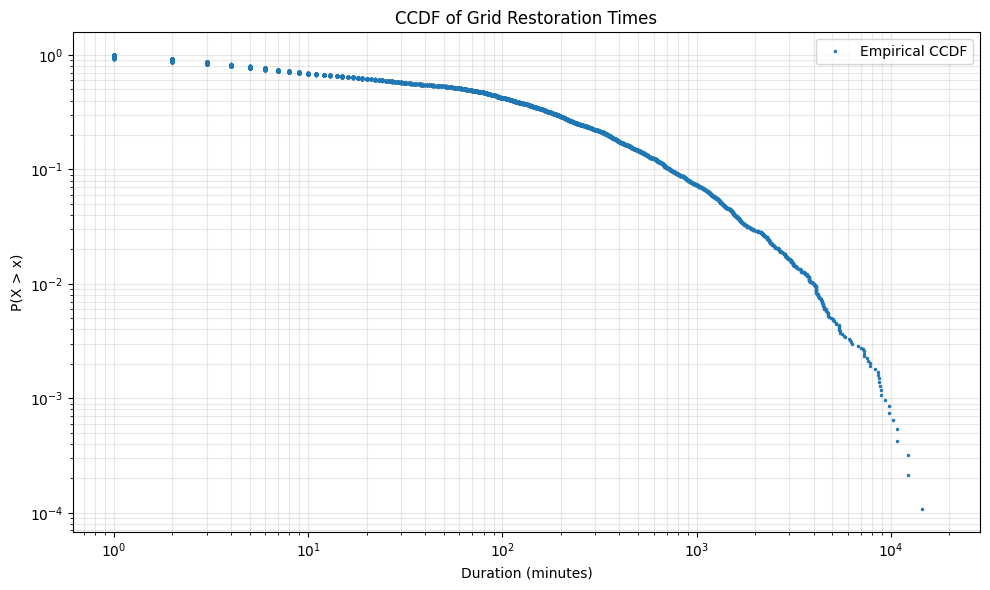

In [3]:
import matplotlib.pyplot as plt
# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 經驗互補累積分布 CCDF = 1 - 累積機率
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
plt.ylabel("P(X > x)")
plt.title("CCDF of Grid Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 3. GMM 擬合

## 3.1 分層離散化

* 對全體 duration 以分位數切為 5 等分，作為後續 Stratified K-Fold 的分層依據，避免重尾分布所造成的 Fold 極端事件資料不平衡的狀況
 
* 分位數分 5 層可避免「結果導向」的固定時間切點，並較能保護尾端的代表性。

In [4]:
# 對全體 duration 做分位數離散化，供 Stratified K-Fold 分層使用
# 依修復時間分為 5 等分（與 road 一致）
df["duration_bin"] = pd.qcut(
    df["Duration (minutes)"],
    q=5,
    labels=False,
    duplicates="drop"
)

# 確認分層分布
bin_count = df["duration_bin"].value_counts().sort_index()
bin_pct   = (bin_count / len(df) * 100).round(1)
display(pd.DataFrame({"Count": bin_count, "Pct (%)": bin_pct}))

,Count,Pct (%)
duration_bin,,
0,1912,20.4
1,1841,19.7
2,1862,19.9
3,1889,20.2
4,1852,19.8


## 3.2 模型擬合與超參數 K 選擇

對 n_components 由 1~10 進行窮舉搜尋，後以 BIC 作為模型選擇準則，取 BIC 最小者作為最佳 component 數

重點觀察 $n=1$（對數常態）與最佳模型的 $\Delta\text{BIC}$：若 $\Delta\text{BIC}$ 很小，代表多族群並未帶來實質改善，對數常態已足夠；若顯著，則 GMM 確實捕捉到單族群對數常態無法描述的結構。

* 結果 : 多族群表現明顯比單純使用對數常態分佈來的好


In [5]:
from sklearn.mixture import GaussianMixture

# 在 log-space 對 data 擬合 1~max_components 的 GMM，以 BIC 選擇模型
# n=1 即為對數常態 (log-space 單一常態)
def fit_gmm(data, max_components=10):
    log_data   = np.log(data).reshape(-1, 1)
    best_gmm   = None
    best_n     = None
    best_bic   = np.inf
    bic_scores = []
    gmm_by_n   = {}

    # 對不同 component 數 n 計算 BIC
    for n in range(1, max_components + 1):
        gmm = GaussianMixture(
            n_components=n,
            random_state=42,
            max_iter=500,     # 最大迭代次數
            tol=1e-3,         # 收斂判斷
            n_init=5          # 多起點初始化，避免 EM 卡在局部最優
        )
        gmm.fit(log_data)

        # 判斷是否收斂
        if not gmm.converged_:
            print(f"n={n} 未收斂，跳過")
            bic_scores.append((n, np.nan))
            continue

        # 計算並記錄 BIC
        bic = gmm.bic(log_data)
        bic_scores.append((n, round(bic, 2)))
        gmm_by_n[n] = gmm

        # 搜尋最佳 GMM
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm
            best_n   = n

    return best_gmm, best_n, bic_scores, gmm_by_n


data = df["Duration (minutes)"].values
best_gmm, best_n, bic_scores, gmm_by_n = fit_gmm(data)

# BIC 表
bic_df = pd.DataFrame(bic_scores, columns=["n_components", "BIC"])
bic_df["ΔBIC (vs best)"] = (bic_df["BIC"] - bic_df["BIC"].min()).round(2)

print(f"最佳 n_components (BIC 最小) : {best_n}")
n1_delta = bic_df.loc[bic_df["n_components"] == 1, "ΔBIC (vs best)"].values[0]
print(f"對數常態 (n=1)相對最佳模型的 ΔBIC : {n1_delta}")
display(bic_df)

最佳 n_components (BIC 最小) : 10
對數常態 (n=1)相對最佳模型的 ΔBIC : 14551.75


,n_components,BIC,ΔBIC (vs best)
0,1,41543.73,14551.75
1,2,40087.61,13095.63
2,3,40073.08,13081.10
3,4,39942.70,12950.72
4,5,32511.90,5519.92
5,6,32501.04,5509.06
6,7,32306.92,5314.94
7,8,32268.66,5276.68
8,9,32297.47,5305.49
9,10,26991.98,0.00


## 3.3 模型擬合與泛化能力評估：Stratified 5-Fold CV

以變異係數（Coefficient of Variation, CV）衡量模型在各 Fold 的 log-likelihood 變異情形，作為模型泛化能力的檢核。


* 結果 : CV 小於 5% 視為模型具備良好泛化能力

In [6]:
from sklearn.model_selection import StratifiedKFold

# 分層取樣
K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
# 修復時間取對數
log_data    = np.log(df["Duration (minutes)"].values)
# 區間標籤
strat_label = df["duration_bin"].values

fold_scores = []

# K-Fold 切分擬合/測試集，逐 fold 擬合與測試
for fold, (train_idx, test_idx) in enumerate(skf.split(log_data, strat_label)):
    X_train = log_data[train_idx].reshape(-1, 1)
    X_test  = log_data[test_idx].reshape(-1, 1)

    # 以選定的 best_n 重新擬合
    gmm = GaussianMixture(n_components=best_n, random_state=42, max_iter=500, n_init=5)
    gmm.fit(X_train)
    fold_scores.append(gmm.score(X_test))

# CV 計算（log-likelihood 為負，分母取絕對值）
mean_ll = np.mean(fold_scores)
std_ll  = np.std(fold_scores)
cv_pct  = std_ll / abs(mean_ll) * 100

print(f"=== Stratified {K}-Fold CV (n_components={best_n}) ===")
for i, s in enumerate(fold_scores):
    print(f"  Fold {i+1}: {s:.4f}")
print(f"  Mean log-likelihood : {mean_ll:.4f} ± {std_ll:.4f}")
print(f"  CV                  : {cv_pct:.2f}%")

=== Stratified 5-Fold CV (n_components=10) ===
  Fold 1: -1.4087
  Fold 2: -1.4703
  Fold 3: -1.4357
  Fold 4: -1.3621
  Fold 5: -1.4375
  Mean log-likelihood : -1.4228 ± 0.0361
  CV                  : 2.54%


# 4. 比較 GMM 與 對數常態分佈

在對數空間下，比較對數常態（$n=1$）與最佳 GMM 的擬合品質。

同一張 log-log CCDF 疊上三條線：原始資料 / 對數常態（$n=1$）/ 最佳 GMM。


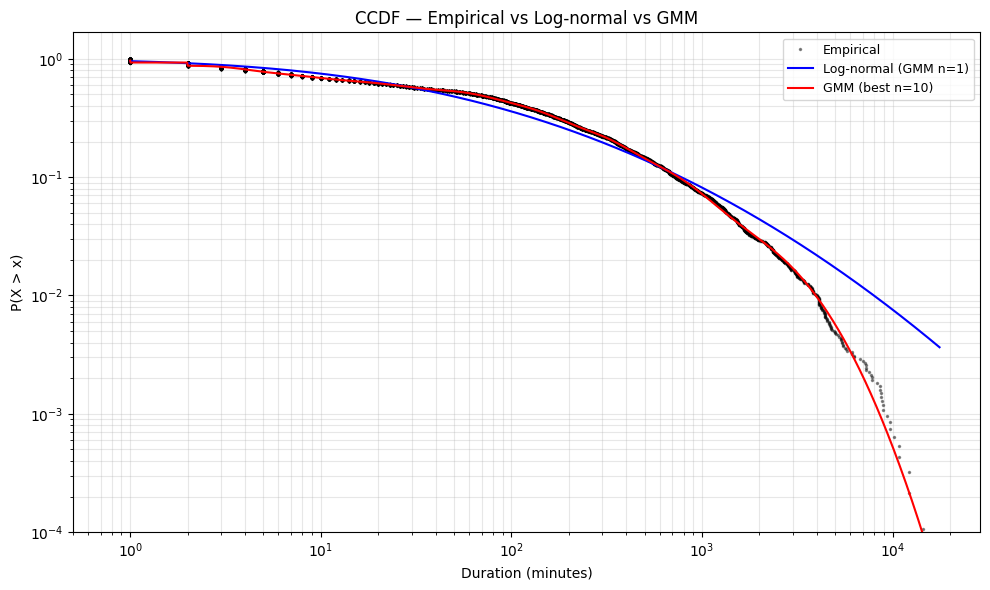

In [7]:
from scipy.stats import norm as sp_norm

def gmm_ccdf_at(x_vals, gmm):
    """
    計算 log-space GMM 在指定 x 值 (分鐘) 的解析 CCDF (超越機率)。
    """
    x_vals  = np.sort(np.asarray(x_vals, dtype=float))
    log_x   = np.log(x_vals)
    cdf     = np.zeros(len(log_x))
    for k in range(gmm.n_components):
        mu_k    = gmm.means_[k, 0]
        sigma_k = np.sqrt(gmm.covariances_[k, 0, 0])
        cdf    += gmm.weights_[k] * sp_norm.cdf((log_x - mu_k) / sigma_k)
    return 1.0 - cdf

# 經驗 CCDF
data_sorted = np.sort(df["Duration (minutes)"].values)
ccdf_emp    = 1 - np.arange(1, len(data_sorted) + 1) / len(data_sorted)

# 解析解 CCDF 曲線（log-space 均勻格點）
x_grid = np.logspace(
    np.log10(data_sorted[0]),
    np.log10(data_sorted[-1]),
    2000
)
c1 = gmm_ccdf_at(x_grid, gmm_by_n[1])
cb = gmm_ccdf_at(x_grid, best_gmm)

plt.figure(figsize=(10, 6))
plt.loglog(data_sorted, ccdf_emp, "k.", markersize=3, alpha=0.4, label="Empirical")
plt.loglog(x_grid, c1, "b-", linewidth=1.5, label="Log-normal (GMM n=1)")
plt.loglog(x_grid, cb, "r-", linewidth=1.5, label=f"GMM (best n={best_n})")
plt.xlim(left=0.5)
plt.ylim(bottom=1e-4)
plt.xlabel("Duration (minutes)")
plt.ylabel("P(X > x)")
plt.title("CCDF — Empirical vs Log-normal vs GMM")   # grid / transformer 自行調整
plt.legend(fontsize=9)
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 5. 相對誤差

**原理**：對每個資料點 $x_i$，計算實際 CCDF 與模型理論 CCDF 之間的相對誤差：

$$\text{rel-err}_i = \frac{\left| \text{CCDF}_{\text{emp}}(x_i) - \text{CCDF}_{\text{model}}(x_i) \right|}{\text{CCDF}_{\text{emp}}(x_i)}$$

模型 CCDF 以**解析式**計算（log-space 各常態 CDF 的加權和），非 Monte Carlo。對數常態與最佳 GMM 並列，直接看 GMM 是否帶來實質改善。

## 5.1 一般統計

In [8]:
from scipy.stats import norm as sp_norm
import numpy as np

def gmm_ccdf_at(x_vals, gmm):
    """
    計算 log-space GMM 在指定 x 值 (分鐘) 的解析 CCDF (超越機率)。
    Parameters
    """
    # 排序防呆：確保輸入為遞增順序（np.interp 等後續插值需嚴格遞增）
    x_vals  = np.sort(np.asarray(x_vals, dtype=float))
    # 對輸入的資料取對數
    log_x   = np.log(x_vals)
    # 建立長度相符的 0 陣列
    cdf     = np.zeros(len(log_x))
    # 所有族群的機率貢獻加權
    for k in range(gmm.n_components):
        mu_k    = gmm.means_[k, 0]
        sigma_k = np.sqrt(gmm.covariances_[k, 0, 0])
        cdf    += gmm.weights_[k] * sp_norm.cdf((log_x - mu_k) / sigma_k)

    return 1.0 - cdf

# 排序
data_sorted = np.sort(df["Duration (minutes)"].values)
n           = len(data_sorted)
# 計算實際機率
ccdf_emp    = 1 - np.arange(1, n + 1) / n

def rel_err_stats(gmm, label):
    # 計算 GMM 超越機率
    ccdf_model = gmm_ccdf_at(data_sorted, gmm)
    mask       = ccdf_emp > 0
    rel_err    = np.abs(ccdf_emp[mask] - ccdf_model[mask]) / ccdf_emp[mask]
    print(f"=== {label} ===")
    print(f"  中位數相對誤差 : {np.median(rel_err)*100:.2f}%")
    print(f"  平均相對誤差   : {np.mean(rel_err)*100:.2f}%")
    print(f"  最大相對誤差   : {rel_err.max()*100:.2f}%")
    print()
    return rel_err

print("── 逐點 CCDF 相對誤差 ──\n")
rel_err_lognorm = rel_err_stats(gmm_by_n[1], "Log-normal")
rel_err_best    = rel_err_stats(best_gmm, f"GMM (best n={best_n})")

── 逐點 CCDF 相對誤差 ──

=== Log-normal ===
  中位數相對誤差 : 8.49%
  平均相對誤差   : 14.08%
  最大相對誤差   : 4350.69%

=== GMM (best n=10) ===
  中位數相對誤差 : 0.67%
  平均相對誤差   : 1.16%
  最大相對誤差   : 43.00%



## 5.2 離散化相對誤差分級表

**誤差判斷標準**

| 誤差範圍 | 評估 |
|---------|------|
| < 5% | 非常好 |
| 5 ~ 10% | 良好 |
| 10 ~ 20% | 尚可 |
| > 20% | 偏差 |

兩模型並列，比較各誤差級距的點數與累積比例。

In [9]:
bins_err   = [(0, 0.05), (0.05, 0.10), (0.10, 0.20), (0.20, np.inf)]
labels_err = ["< 5%（非常好）", "5 ~ 10%（良好）", "10 ~ 20%（尚可）", "> 20%（偏差）"]

def err_table(rel_err, label):
    rows       = []
    cumulative = 0.0
    for (lo, hi), lab in zip(bins_err, labels_err):
        cnt = int(((rel_err >= lo) & (rel_err < hi)).sum())
        pct = cnt / len(rel_err) * 100
        cumulative += pct
        rows.append({"誤差區間": lab, "點數": cnt,
                     "比例 (%)": round(pct, 1), "累積比例 (%)": round(cumulative, 1)})
    tbl = pd.DataFrame(rows).set_index("誤差區間")
    print(f"=== {label} ===")
    display(tbl)

err_table(rel_err_lognorm, "Log-normal (GMM n=1)")
err_table(rel_err_best, f"GMM (best n={best_n})")

=== Log-normal (GMM n=1) ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,2860,30.6,30.6
5 ~ 10%（良好）,2548,27.2,57.8
10 ~ 20%（尚可）,3426,36.6,94.4
> 20%（偏差）,521,5.6,100.0


=== GMM (best n=10) ===


,點數,比例 (%),累積比例 (%)
誤差區間,,,
< 5%（非常好）,9193,98.3,98.3
5 ~ 10%（良好）,99,1.1,99.3
10 ~ 20%（尚可）,36,0.4,99.7
> 20%（偏差）,27,0.3,100.0


# 6. 存檔

In [10]:
import json

params_path = os.path.join(DATA_DIR, "repair_params.json")
all_params  = json.load(open(params_path)) if os.path.exists(params_path) else {}

all_params["grid"] = {
    "n_components": int(best_gmm.n_components),
    "weights":      best_gmm.weights_.tolist(),
    "means":        best_gmm.means_.flatten().tolist(),
    "stds":         np.sqrt(best_gmm.covariances_.flatten()).tolist(),
}

with open(params_path, "w") as f:
    json.dump(all_params, f, indent=2, ensure_ascii=False)

print(json.dumps(all_params["grid"], indent=2, ensure_ascii=False))

{
  "n_components": 10,
  "weights": [
    0.0687259481312021,
    0.1519651644622256,
    0.10441110136204822,
    0.09169940417930586,
    0.14009550187647052,
    0.12049589242028369,
    0.04503318956775515,
    0.10956898255526785,
    0.1119122440523112,
    0.05609257139312988
  ],
  "means": [
    0.0,
    5.112777712928283,
    2.1957051022427962,
    6.73146871361076,
    4.354779897154773,
    1.3921158060222056,
    7.808972331416723,
    3.221627227856767,
    5.900549348739138,
    0.6931471805599537
  ],
  "stds": [
    0.001,
    0.3035901394257133,
    0.33707200554463107,
    0.4063542824328263,
    0.3176377792576938,
    0.28482445179676463,
    0.6183027249936068,
    0.3640281992576652,
    0.30540012641842434,
    0.001
  ]
}
